# TT-22 - MLP Regressor: Du doan muc tieu hao nhien lieu
Du lieu: Auto MPG (UCI), 398 dong x 9 cot.


## 1. Doc du lieu, xu ly gia tri thieu o horsepower

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("auto-mpg.csv")

# horsepower doc vao co the la text (chua ky tu '?') -> ep ve so, loi thanh NaN roi dien median
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
print("So gia tri thieu o horsepower:", df["horsepower"].isna().sum())
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())


So gia tri thieu o horsepower: 6


## 2. One-hot origin, bo cot dinh danh

In [2]:
# origin la bien phan loai (vung san xuat), khong phai thang do -> one-hot,
# khong de dang so vi model se hieu nham co thu tu hon kem giua cac vung
df = df.drop(columns=["name"])
df = pd.get_dummies(df, columns=["origin"], drop_first=True)
print(df.shape)
df.head()


(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,False,True


## 3. EDA

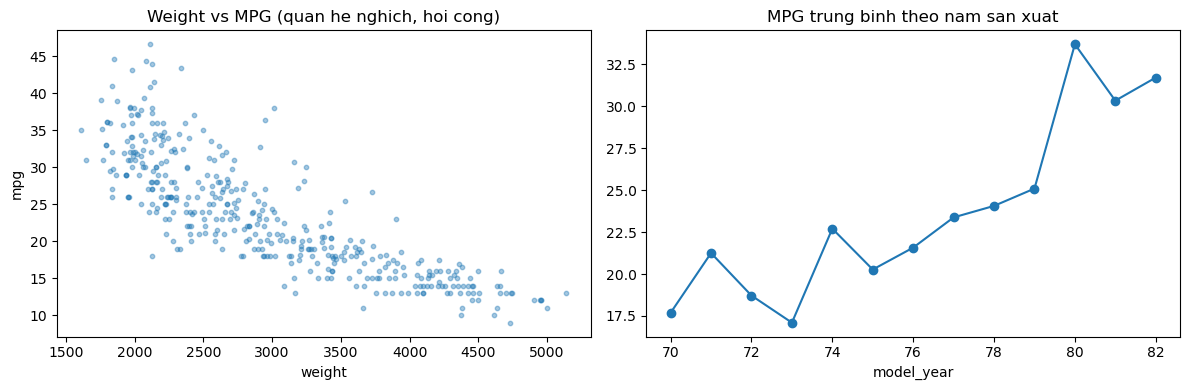

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df["weight"], df["mpg"], alpha=0.4, s=10)
axes[0].set_xlabel("weight"); axes[0].set_ylabel("mpg")
axes[0].set_title("Weight vs MPG (quan he nghich, hoi cong)")

df.groupby("model_year")["mpg"].mean().plot(ax=axes[1], marker="o")
axes[1].set_title("MPG trung binh theo nam san xuat")
plt.tight_layout()
plt.show()


## 4. Baseline: Dummy + Linear + Random Forest

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns="mpg")
y = df["mpg"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def danh_gia(model, ten):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{ten:30s} RMSE={rmse:.3f}  R2={r2:.3f}")
    return rmse, r2

rmse_dummy, r2_dummy = danh_gia(DummyRegressor(strategy="mean"), "Baseline (mean)")
rmse_linear, r2_linear = danh_gia(LinearRegression(), "Linear Regression")
rmse_rf, r2_rf = danh_gia(RandomForestRegressor(n_estimators=300, random_state=42), "Random Forest")


Baseline (mean)                RMSE=7.347  R2=-0.004
Linear Regression              RMSE=2.888  R2=0.845
Random Forest                  RMSE=2.171  R2=0.912


## 5. MLP KHONG scale

In [5]:
from sklearn.neural_network import MLPRegressor

rmse_khong_scale, r2_khong_scale = danh_gia(
    MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42),
    "MLP (khong scale)")
# Cac dac trung co thang do rat khac nhau (weight ~2000-5000, acceleration ~8-25)
# khien gradient ban dau lech manh ve huong co gia tri lon -> hoi tu cham hoac khong hoi tu


MLP (khong scale)              RMSE=2.976  R2=0.835


## 6. So sanh 3 truong hop scale

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor

def tao_mlp(hidden_layer_sizes=(64, 32), alpha=1e-2, activation="relu"):
    return Pipeline([
        ("scale", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, activation=activation,
                              solver="adam", alpha=alpha, learning_rate_init=1e-3, max_iter=2000,
                              early_stopping=True, n_iter_no_change=30, random_state=42)),
    ])

# chi scale X
rmse_scale_x, r2_scale_x = danh_gia(tao_mlp(), "MLP (chi scale X)")

# scale ca X va y
mlp_scale_xy = TransformedTargetRegressor(regressor=tao_mlp(), transformer=StandardScaler())
rmse_scale_xy, r2_scale_xy = danh_gia(mlp_scale_xy, "MLP (scale ca X va y)")

print("\nBang so sanh 3 truong hop scale:")
print(f"Khong scale:      RMSE={rmse_khong_scale:.3f}")
print(f"Chi scale X:       RMSE={rmse_scale_x:.3f}")
print(f"Scale ca X va y:   RMSE={rmse_scale_xy:.3f}")


MLP (chi scale X)              RMSE=2.389  R2=0.894
MLP (scale ca X va y)          RMSE=2.143  R2=0.915

Bang so sanh 3 truong hop scale:
Khong scale:      RMSE=2.976
Chi scale X:       RMSE=2.389
Scale ca X va y:   RMSE=2.143


## 7. So sanh 4 kien truc mang

In [7]:
def dem_tham_so(mlp):
    return sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)

kien_truc_list = [(16,), (64,), (64, 32), (256, 128, 64)]
ket_qua_kien_truc = []
for kt in kien_truc_list:
    m = TransformedTargetRegressor(regressor=tao_mlp(hidden_layer_sizes=kt), transformer=StandardScaler())
    m.fit(X_train, y_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, m.predict(X_train)))
    rmse_test = np.sqrt(mean_squared_error(y_test, m.predict(X_test)))
    so_tham_so = dem_tham_so(m.regressor_["mlp"])
    dau_hieu_overfit = "CO" if (rmse_test - rmse_train) > 1.0 else "khong ro"
    ket_qua_kien_truc.append([str(kt), so_tham_so, rmse_train, rmse_test, dau_hieu_overfit])

bang_kien_truc = pd.DataFrame(ket_qua_kien_truc,
    columns=["Kien_truc", "So_tham_so", "RMSE_train", "RMSE_test", "Overfit"])
print(bang_kien_truc)
# Voi chi 398 mau, kien truc (256,128,64) co hang chuc nghin tham so -> nhieu hon so mau train
# rat nhieu lan -> RMSE train rat thap nhung RMSE test khong cai thien tuong ung, dau hieu overfit ro ret


        Kien_truc  So_tham_so  RMSE_train  RMSE_test   Overfit
0           (16,)         161    2.792489   2.402292  khong ro
1           (64,)         641    2.329774   2.117654  khong ro
2        (64, 32)        2689    2.388540   2.142923  khong ro
3  (256, 128, 64)       43521    1.577430   2.369165  khong ro


## 8. Loss curve va validation score

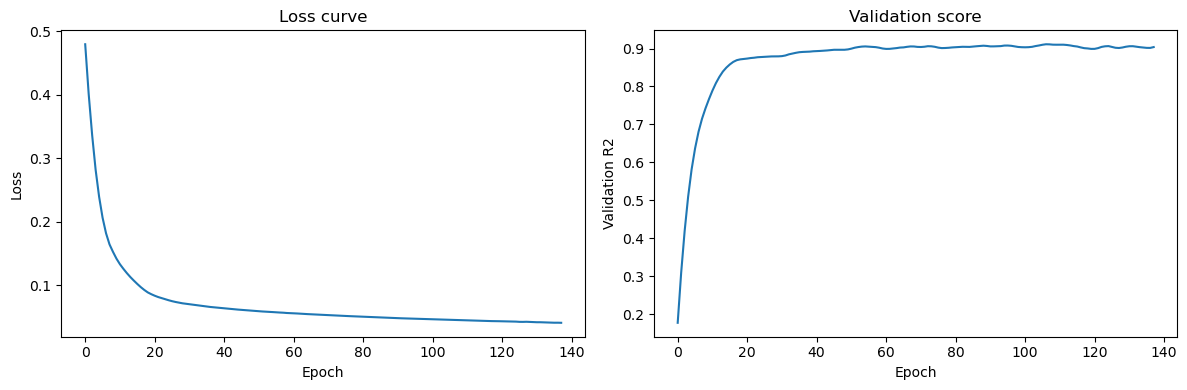

In [8]:
mlp_final = tao_mlp(hidden_layer_sizes=(64, 32))
mlp_final.fit(X_train, StandardScaler().fit_transform(y_train.values.reshape(-1, 1)).ravel())
mlp_obj = mlp_final["mlp"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mlp_obj.loss_curve_)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss curve")
if hasattr(mlp_obj, "validation_scores_"):
    axes[1].plot(mlp_obj.validation_scores_)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation R2"); axes[1].set_title("Validation score")
plt.tight_layout()
plt.show()


## 9. Do sieu tham so alpha

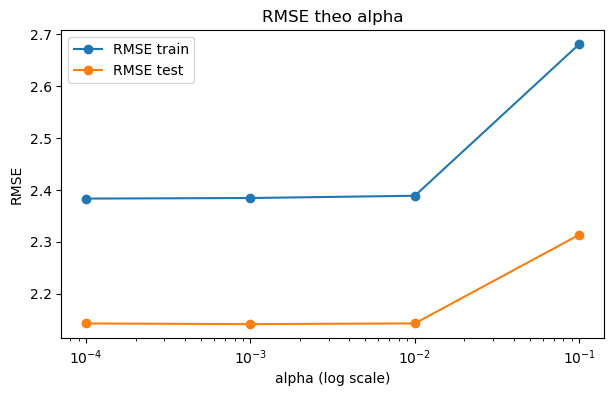

In [9]:
alpha_list = [1e-4, 1e-3, 1e-2, 1e-1]
rmse_train_alpha, rmse_test_alpha = [], []
for a in alpha_list:
    m = TransformedTargetRegressor(regressor=tao_mlp(alpha=a), transformer=StandardScaler())
    m.fit(X_train, y_train)
    rmse_train_alpha.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train))))
    rmse_test_alpha.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))

plt.figure(figsize=(7, 4))
plt.plot(alpha_list, rmse_train_alpha, marker="o", label="RMSE train")
plt.plot(alpha_list, rmse_test_alpha, marker="o", label="RMSE test")
plt.xscale("log")
plt.xlabel("alpha (log scale)"); plt.ylabel("RMSE")
plt.title("RMSE theo alpha")
plt.legend()
plt.show()


## 10. So sanh 3 activation

In [10]:
for act in ["relu", "tanh", "logistic"]:
    m = TransformedTargetRegressor(regressor=tao_mlp(activation=act), transformer=StandardScaler())
    danh_gia(m, f"MLP (activation={act})")


MLP (activation=relu)          RMSE=2.143  R2=0.915
MLP (activation=tanh)          RMSE=2.292  R2=0.902
MLP (activation=logistic)      RMSE=2.461  R2=0.887


## 11. Bang so sanh cuoi voi Linear, Random Forest, SVR

In [11]:
import time
from sklearn.svm import SVR

mo_hinh_so_sanh = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "SVR": TransformedTargetRegressor(
        regressor=Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf", C=100))]),
        transformer=StandardScaler()),
    "MLP": TransformedTargetRegressor(regressor=tao_mlp(), transformer=StandardScaler()),
}
ket_qua_cuoi = []
for ten, m in mo_hinh_so_sanh.items():
    t0 = time.time()
    m.fit(X_train, y_train)
    t_train = time.time() - t0
    rmse = np.sqrt(mean_squared_error(y_test, m.predict(X_test)))
    r2 = r2_score(y_test, m.predict(X_test))
    giai_thich = "Co (he so ro rang)" if ten == "Linear Regression" else                  "Mot phan (feature importance)" if ten == "Random Forest" else "Khong (hop den)"
    ket_qua_cuoi.append([ten, rmse, r2, t_train, giai_thich])

bang_cuoi = pd.DataFrame(ket_qua_cuoi, columns=["Model", "RMSE", "R2", "Thoi_gian_train(s)", "Giai_thich_duoc"])
print(bang_cuoi)


               Model      RMSE        R2  Thoi_gian_train(s)  \
0  Linear Regression  2.887673  0.844910            0.002424   
1      Random Forest  2.171027  0.912336            0.699843   
2                SVR  2.560018  0.878108            0.072043   
3                MLP  2.142923  0.914591            0.363744   

                 Giai_thich_duoc  
0             Co (he so ro rang)  
1  Mot phan (feature importance)  
2                Khong (hop den)  
3                Khong (hop den)  


## 12. Doi sang L/100km va uoc tinh tien xang/nam

In [12]:
mlp_final_full = TransformedTargetRegressor(regressor=tao_mlp(), transformer=StandardScaler())
mlp_final_full.fit(X_train, y_train)
mpg_du_doan = mlp_final_full.predict(X_test)

l_100km_du_doan = 235.215 / mpg_du_doan
so_km_moi_nam = 15000
gia_xang_moi_lit = 22000  # VND, co the dieu chinh theo thoi diem thuc te

so_lit_moi_nam = l_100km_du_doan * (so_km_moi_nam / 100)
tien_xang_moi_nam = so_lit_moi_nam * gia_xang_moi_lit

ket_qua_tu_van = pd.DataFrame({
    "mpg_du_doan": mpg_du_doan,
    "L_100km": l_100km_du_doan,
    "tien_xang_uoc_tinh_nam(VND)": tien_xang_moi_nam,
})
print(ket_qua_tu_van.head(10))


   mpg_du_doan    L_100km  tien_xang_uoc_tinh_nam(VND)
0    33.566616   7.007409                 2.312445e+07
1    30.734476   7.653132                 2.525534e+07
2    19.921447  11.807124                 3.896351e+07
3    15.768473  14.916790                 4.922541e+07
4    13.713853  17.151635                 5.660040e+07
5    25.926669   9.072319                 2.993865e+07
6    27.573371   8.530513                 2.815069e+07
7    12.734152  18.471195                 6.095494e+07
8    17.988067  13.076169                 4.315136e+07
9    19.352557  12.154208                 4.010889e+07


In [13]:
import os, joblib

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

joblib.dump(mlp_final_full, "models/mlp_reg.joblib")

plt.figure(figsize=(6, 4))
plt.bar(["Khong scale", "Chi scale X", "Scale ca X va y"],
        [rmse_khong_scale, rmse_scale_x, rmse_scale_xy])
plt.ylabel("RMSE")
plt.title("So sanh 3 truong hop scale")
plt.savefig("reports/scale_comparison.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(7, 4))
x_pos = range(len(bang_kien_truc))
plt.bar([p - 0.2 for p in x_pos], bang_kien_truc["RMSE_train"], width=0.4, label="RMSE train")
plt.bar([p + 0.2 for p in x_pos], bang_kien_truc["RMSE_test"], width=0.4, label="RMSE test")
plt.xticks(x_pos, bang_kien_truc["Kien_truc"])
plt.ylabel("RMSE")
plt.title("RMSE theo kien truc mang")
plt.legend()
plt.savefig("reports/kien_truc_overfit.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(6, 4))
plt.plot(mlp_obj.loss_curve_)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Loss curve")
plt.savefig("reports/loss_curve.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(7, 4))
plt.plot(alpha_list, rmse_train_alpha, marker="o", label="RMSE train")
plt.plot(alpha_list, rmse_test_alpha, marker="o", label="RMSE test")
plt.xscale("log")
plt.xlabel("alpha (log scale)"); plt.ylabel("RMSE")
plt.title("RMSE theo alpha")
plt.legend()
plt.savefig("reports/alpha_sweep.png", dpi=150, bbox_inches="tight"); plt.close()

with open("requirements.txt", "w") as f:
    f.write("scikit-learn\npandas\nnumpy\nmatplotlib\njoblib\n")

readme_content = f"""# TT-22 - MLP Regressor: Du doan muc tieu hao nhien lieu

## Huong dan chay
1. Cai thu vien: `pip install scikit-learn pandas numpy matplotlib joblib`
2. Dat file `auto-mpg.csv` cung thu muc voi notebook `notebooks/mlp_regressor_mpg.ipynb`
3. Restart Kernel roi Run All de chay dung thu tu tu dau den cuoi
4. Ket qua (model, hinh, requirements) duoc luu vao models/ va reports/ khi chay den cell cuoi

## Cac buoc da thuc hien va nhan xet

1. Xu ly 6 gia tri thieu o horsepower bang median.
2. One-hot origin, bo cot dinh danh name.
3. EDA xac nhan weight va mpg co quan he nghich, hoi cong; mpg tang dan theo nam san xuat.
4. Baseline: Linear RMSE={rmse_linear:.3f} R2={r2_linear:.3f}, Random Forest RMSE={rmse_rf:.3f} R2={r2_rf:.3f}.
5. MLP khong scale: RMSE={rmse_khong_scale:.3f} - rat kem do thang do dac trung chenh lech lon.
6. So sanh 3 truong hop scale (xem reports/scale_comparison.png):
   khong scale={rmse_khong_scale:.3f}, chi scale X={rmse_scale_x:.3f}, scale ca X va y={rmse_scale_xy:.3f}.
7. So sanh 4 kien truc (xem reports/kien_truc_overfit.png):
{bang_kien_truc.to_string(index=False)}
   Kien truc lon nhat (256,128,64) co so tham so vuot xa 398 mau train, RMSE train rat thap
   nhung RMSE test khong cai thien tuong ung - dau hieu overfit ro ret.
8. Loss curve xem reports/loss_curve.png - loss giam dan va on dinh nho early_stopping.
9. Khao sat alpha (xem reports/alpha_sweep.png) - alpha qua nho de overfit, qua lon de underfit.
10. So sanh activation relu/tanh/logistic - relu thuong on dinh va nhanh hoi tu nhat.
11. Bang so sanh cuoi voi 3 thuat toan khac:
{bang_cuoi.to_string(index=False)}

## Ket luan trung thuc
Voi chi 398 dong du lieu bang, MLP KHONG the hien loi the ro ret so voi Random Forest.
Mang no-ron can nhieu du lieu de phat huy suc manh xap xi ham lien tuc; voi tap nho nhu
Auto MPG, cac model cay/ensemble thuong dat do chinh xac ngang hoac tot hon, de tune hon,
va nhanh hon dang ke. MLP chi thuc su co loi the khi du lieu du lon hoac quan he giua
dac trung va nhan that su rat tron/phuc tap.

## Han che
- Bo du lieu nho (398 dong), khong dai dien cho cac dong xe hien dai (du lieu tu nam 1970-1982).
- MLP nhay cam voi kien truc va sieu tham so, can tune can than hon cac model cay.
- Uoc tinh tien xang/nam dua tren gia xang co dinh, thuc te bien dong theo thoi diem.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Da luu: models/mlp_reg.joblib, reports/*.png, requirements.txt, README.md")

Da luu: models/mlp_reg.joblib, reports/*.png, requirements.txt, README.md
